# Example of using `k`-means to segment realistic customer data

Here's a worked example of using K-means clustering to segment a realistic customer dataset for targeted marketing. We'll walk through:

- Simulating realistic customer data
- Preprocessing
- Running K-means
- Analyzing and labeling segments
- Marketing strategy per segment

## Simulate Customer Dataset

We're creating a realistic, synthetic dataset to mimic typical customer features used in marketing:

- Age
- Annual Income (k$)
- Spending Score (1–100)
- Online Engagement (1–10)
- Region (categorical)

These features are common inputs in marketing analytics. Clustering based on them helps uncover patterns like "high-value young customers" or "low-engagement older shoppers."

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_customers = 300
data = pd.DataFrame({
    'Age': np.random.normal(35, 10, n_customers).astype(int),
    'Annual Income (k$)': np.random.normal(60, 20, n_customers).astype(int),
    'Spending Score': np.random.randint(1, 101, n_customers),
    'Online Engagement': np.random.randint(1, 11, n_customers),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], n_customers)
})


## Preprocessing the Data

- Encoding categorical variables: We one-hot encode Region so that it's usable in numerical clustering algorithms.
- Feature scaling: We standardize the data using StandardScaler.

We do this because K-means uses Euclidean distance, which is sensitive to feature scale. Unscaled data can bias clustering toward variables with larger numeric ranges.

Encoding turns categories like "North" or "South" into numbers that K-means can process.


In [2]:
from sklearn.preprocessing import StandardScaler

data_encoded = pd.get_dummies(data, columns=['Region'], drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_encoded)

## Choosing Number of Clusters and Fitting K-Means

- We run K-means for various values of `k` (1 to 9).
- We use the elbow method to determine the best number of clusters.
- We fit the final K-means model and assign each customer to a cluster.

Choosing the right `k` is critical. Too few clusters will miss nuance; too many creates noise.

The elbow point shows where adding more clusters yields diminishing returns in explaining the data variance.


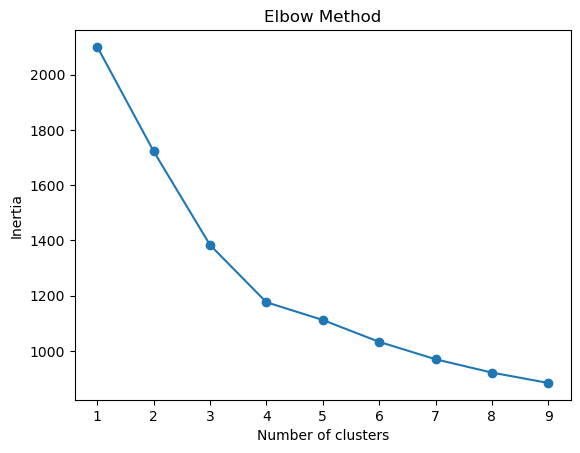

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Fit final model (we assume 4 clusters will be picked after elbow method)
kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)


## Analyze and Label Customer Segments

- We group the data by cluster and compute average feature values.
- Based on the statistical profile of each group, we assign descriptive labels to help interpret and communicate the meaning of each segment. 
 
  *Note: This labeling step is subjective. You assign labels based on domain knowledge and marketing logic. Tools like boxplots and customer interviews can further refine this.*

Clusters are just numbers (e.g., Cluster 0, 1). To use them in marketing, we must interpret what they mean.
Labeling turns raw clusters into personas, like "Young High Spenders" or "Disengaged Seniors."

In [4]:
cluster_summary = data.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)


               Age  Annual Income (k$)  Spending Score  Online Engagement
Cluster                                                                  
0        32.886076           59.075949       49.911392           6.151899
1        33.444444           62.308642       48.172840           5.271605
2        36.605634           58.154930       45.845070           4.746479
3        35.043478           56.086957       54.579710           5.884058


## 3D visualisation of customer segments

Here's how to create a 3D visualization of your customer clusters using Principal Component Analysis (PCA) to reduce the data to three dimensions and then plot with matplotlib.

This visualization helps you see the separation between clusters and interpret how distinct or overlapping they are, which can be useful when presenting your segmentation analysis.

We reduce the scaled feature space to 3 principal components using PCA (which captures the majority of variance) and then plot each customer colored by cluster.

- K-means clustering works in high-dimensional space, but that’s hard to visualize.
- 3D PCA plots help you intuitively understand the shape, size, and separation of clusters.

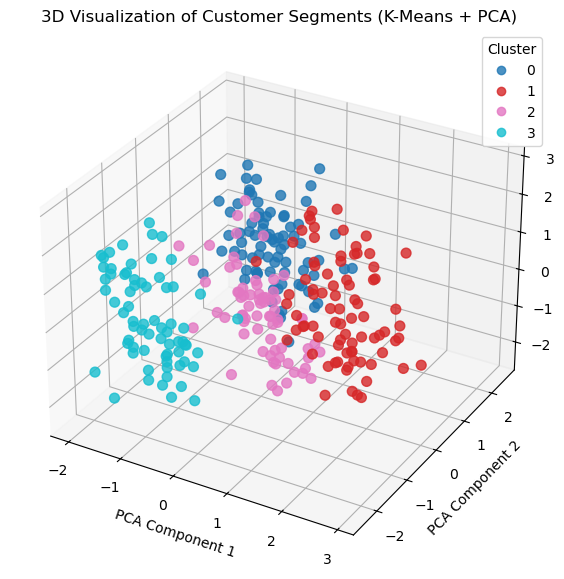

In [5]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Reduce to 3 principal components
pca = PCA(n_components=3)
components = pca.fit_transform(X_scaled)

# Add PCA components to the DataFrame for plotting
data['PCA1'] = components[:, 0]
data['PCA2'] = components[:, 1]
data['PCA3'] = components[:, 2]

# 3D Scatter Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot each cluster in a different color
scatter = ax.scatter(
    data['PCA1'],
    data['PCA2'],
    data['PCA3'],
    c=data['Cluster'],
    cmap='tab10',
    s=50,
    alpha=0.8
)

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D Visualization of Customer Segments (K-Means + PCA)')
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


## Interpretation 

If clusters are well-separated, K-means has likely found meaningful groupings.

If there's significant overlap, consider:

- Adding more features
- Trying different values of k
- Using other clustering methods (e.g. DBSCAN, Gaussian Mixture Models)

## Outputting the data with assigned clusters

This sample code repeats the analysis and adds a column to the data output representing which cluster each row fits in. This would be needed in order to use the results of the analysis to assign different customers to different campaigns.

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Generate synthetic customer data
np.random.seed(42)
n_customers = 300

data = pd.DataFrame({
    'CustomerID': np.arange(1, n_customers + 1),
    'Age': np.random.normal(35, 10, n_customers).astype(int),
    'Annual Income (k$)': np.random.normal(60, 20, n_customers).astype(int),
    'Spending Score': np.random.randint(1, 101, n_customers),
    'Online Engagement': np.random.randint(1, 11, n_customers),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], n_customers)
})

# 2. Preprocess: one-hot encode Region and scale numerical features
data_encoded = pd.get_dummies(data, columns=['Region'], drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_encoded.drop(columns=['CustomerID']))

# 3. Apply K-means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Output the resulting DataFrame
print(data.head())


   CustomerID  Age  Annual Income (k$)  Spending Score  Online Engagement  \
0           1   39                  43              47                  7   
1           2   33                  48              68                  8   
2           3   41                  74              76                  3   
3           4   50                  72              45                  6   
4           5   32                  59               2                  2   

  Region  Cluster  
0  North        3  
1  North        3  
2   East        2  
3   East        2  
4   East        2  


## Focusing on customer behaviour

K-means treats all features equally when calculating clusters.

But in marketing we are trying to influence behaviour around buying, so it makes sense to look for segments that represent differences in behaviour.

If (below) we look at how `Spending Score`, `Income` and `Online Engagement` are spread across clusters we can see each cluster has a similar data spread iof each of these features, so the clustering doesn't really distinguish based on these behavioural indicators.


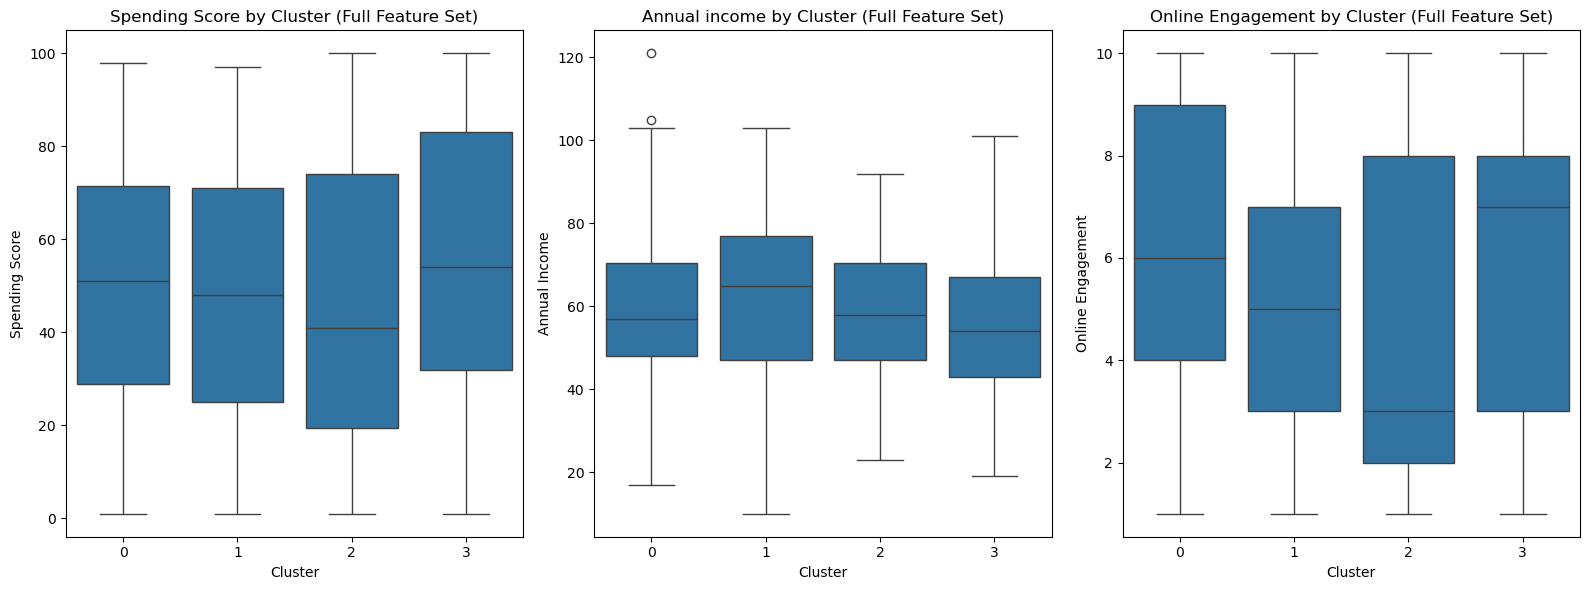

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Simulate customer data
np.random.seed(42)
n_customers = 300
data = pd.DataFrame({
    'Age': np.random.normal(35, 10, n_customers).astype(int),
    'Annual Income (k$)': np.random.normal(60, 20, n_customers).astype(int),
    'Spending Score': np.random.randint(1, 101, n_customers),
    'Online Engagement': np.random.randint(1, 11, n_customers),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], n_customers)
})

# One-hot encode region
data_encoded = pd.get_dummies(data, columns=['Region'], drop_first=True)

# --- Standard Clustering ---
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(data_encoded)

kmeans_full = KMeans(n_clusters=4, random_state=42)
data['Cluster_Full'] = kmeans_full.fit_predict(X_full_scaled)

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

sns.boxplot(x='Cluster_Full', y='Spending Score', data=data, ax=axes[0])
axes[0].set_title('Spending Score by Cluster (Full Feature Set)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Spending Score')

sns.boxplot(x='Cluster_Full', y='Annual Income (k$)', data=data, ax=axes[1])
axes[1].set_title('Annual income by Cluster (Full Feature Set)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Annual Income')

sns.boxplot(x='Cluster_Full', y='Online Engagement', data=data, ax=axes[2])
axes[2].set_title('Online Engagement by Cluster (Full Feature Set)')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Online Engagement')

plt.tight_layout()
plt.show()



### Focusing on behavioural features

By contrast, if we only cluster based on the behavioural features we are interested in, we get a different result, showing clear differentiation between clusters based on our behavioural features:

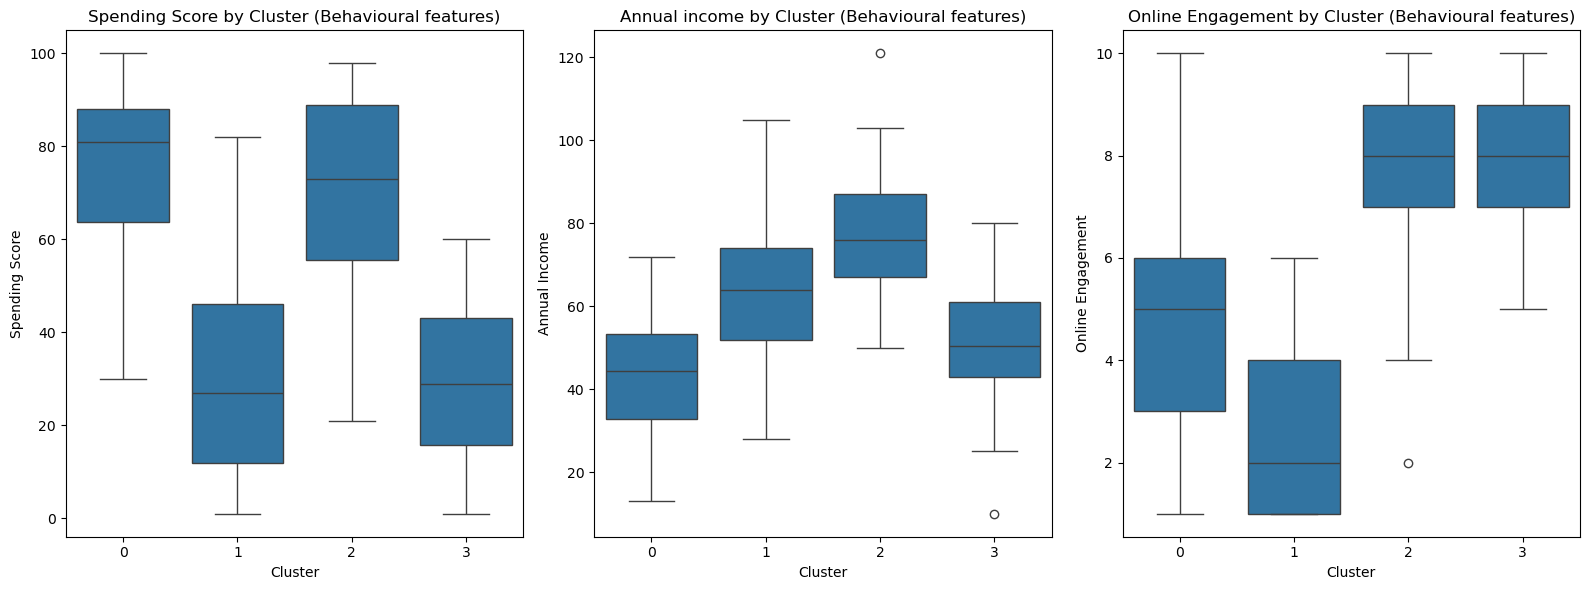

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Simulate customer data
np.random.seed(42)
n_customers = 300
data = pd.DataFrame({
    'Age': np.random.normal(35, 10, n_customers).astype(int),
    'Annual Income (k$)': np.random.normal(60, 20, n_customers).astype(int),
    'Spending Score': np.random.randint(1, 101, n_customers),
    'Online Engagement': np.random.randint(1, 11, n_customers),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], n_customers)
})

# One-hot encode region
data_encoded = pd.get_dummies(data, columns=['Region'], drop_first=True)


# --- Behavior-Driven Clustering  ---
# Use only spending score + behavioral features
features_behavior = ['Spending Score', 'Online Engagement', 'Annual Income (k$)']
X_behavior = data[features_behavior]

X_behavior_scaled = scaler.fit_transform(X_behavior)
kmeans_behavior = KMeans(n_clusters=4, random_state=42)
data['Cluster_Behavior'] = kmeans_behavior.fit_predict(X_behavior_scaled)

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

sns.boxplot(x='Cluster_Behavior', y='Spending Score', data=data, ax=axes[0])
axes[0].set_title('Spending Score by Cluster (Behavioural features)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Spending Score')

sns.boxplot(x='Cluster_Behavior', y='Annual Income (k$)', data=data, ax=axes[1])
axes[1].set_title('Annual income by Cluster (Behavioural features)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Annual Income')

sns.boxplot(x='Cluster_Behavior', y='Online Engagement', data=data, ax=axes[2])
axes[2].set_title('Online Engagement by Cluster (Behavioural features)')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Online Engagement')

plt.tight_layout()
plt.show()

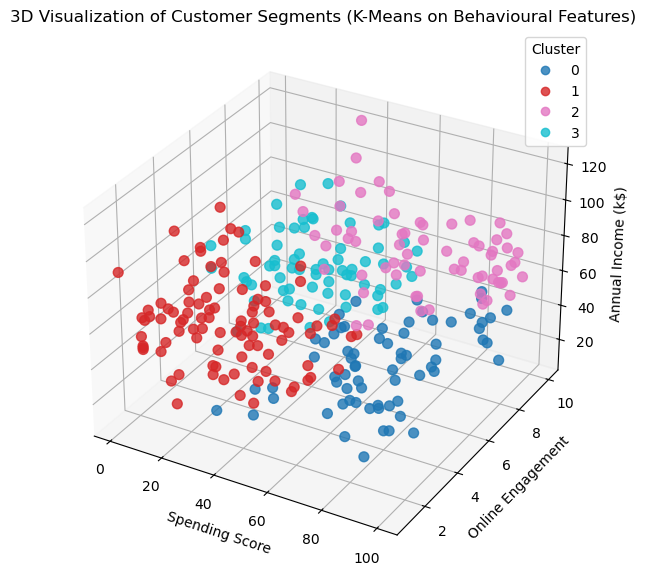

In [ ]:

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

data['Cluster'] = kmeans.fit_predict(X_behavior_scaled)

# 3D Scatter Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot each cluster in a different color
scatter = ax.scatter(
    data['Spending Score'],
    data['Online Engagement'],
    data['Annual Income (k$)'],
    c=data['Cluster'],
    cmap='tab10',
    s=50,
    alpha=0.8
)

ax.set_xlabel('Spending Score')
ax.set_ylabel('Online Engagement')
ax.set_zlabel('Annual Income (k$)')

ax.set_title('3D Visualization of Customer Segments (K-Means on Behavioural Features)')
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

With a different charting library ([Plotly](https://plotly.com/python/)) we can create an interactive chart that makes it easier to visualise the clusters:

In [14]:
import plotly.express as px
import pandas as pd
import numpy as np


# Create interactive 3D scatter plot
fig = px.scatter_3d(data, x='Spending Score', y='Online Engagement', z='Annual Income (k$)', color='Cluster',
                    title='Interactive 3D Scatter Plot of Clusters',
                    labels={'x': 'X Axis', 'y': 'Y Axis', 'z': 'Z Axis'})

# Show the plot
fig.show()
